In [1]:
# Unemployment Analysis with Python
# Data Science Internship Task 2
# Sujal Maurya

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [6]:
df = pd.read_csv("Unemployment_in_India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [26]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:")
for col in df.columns:
    print("-", col)

print("\nData Types:")
print(df.dtypes)

print("\nMemory Usage:")
print(df.memory_usage(deep=True).sum() / 1024, "KB")

print("\nFirst 5 Records:")
display(df.head())

DATASET OVERVIEW

Number of Rows    : 741
Number of Columns : 7

Column Names:
- Region
- Date
- Frequency
- Estimated Unemployment Rate (%)
- Estimated Employed
- Estimated Labour Participation Rate (%)
- Area

Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

Memory Usage:
150.9560546875 KB

First 5 Records:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [25]:
# Data Cleaning

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True,
    errors='coerce'
)

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Check missing values
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns with median
numerical_cols = df.select_dtypes(include=['float64','int64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)


Missing Values Before Cleaning:
Region                                     1
Date                                       1
Frequency                                  1
Estimated Unemployment Rate (%)            1
Estimated Employed                         1
Estimated Labour Participation Rate (%)    1
Area                                       1
dtype: int64

Missing Values After Cleaning:
Region                                     0
Date                                       1
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Dataset Shape After Cleaning:
(741, 7)


In [10]:
df.describe(include='all')

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
count,740,740,740,740.000000,7.400000e+02,740.000000,740
unique,28,NaN,2,NaN,NaN,NaN,2
top,Andhra Pradesh,NaN,Monthly,NaN,NaN,NaN,Urban
freq,28,NaN,381,NaN,NaN,NaN,381
mean,NaN,2019-12-12 18:36:58.378378496,NaN,11.787946,7.204460e+06,42.630122,NaN
min,NaN,2019-05-31 00:00:00,NaN,0.000000,4.942000e+04,13.330000,NaN
25%,NaN,2019-08-31 00:00:00,NaN,4.657500,1.190404e+06,38.062500,NaN
50%,NaN,2019-11-30 00:00:00,NaN,8.350000,4.744178e+06,41.160000,NaN
75%,NaN,2020-03-31 00:00:00,NaN,15.887500,1.127549e+07,45.505000,NaN
max,NaN,2020-06-30 00:00:00,NaN,76.740000,4.577751e+07,72.570000,NaN


In [11]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


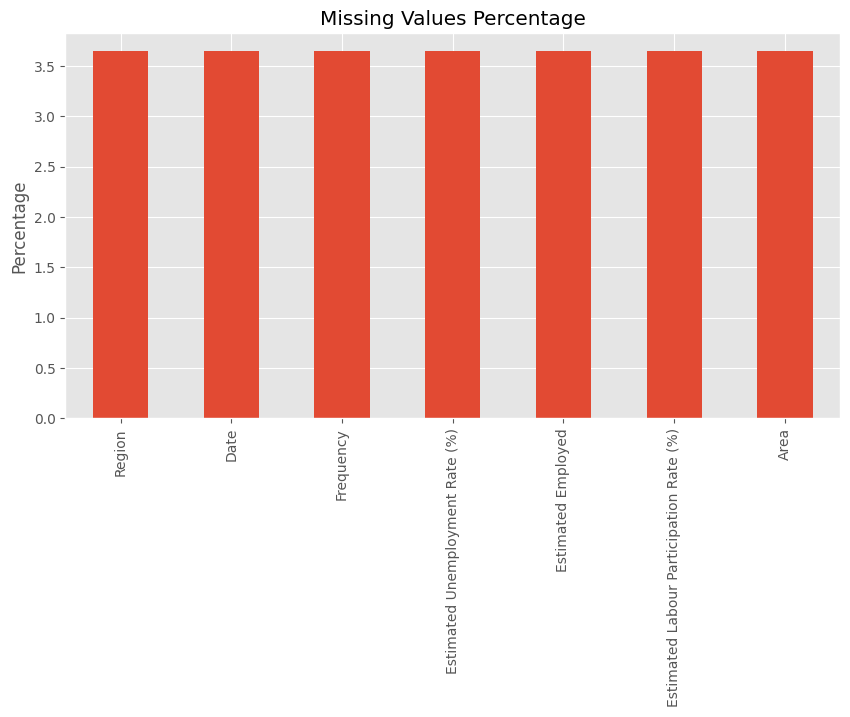

In [12]:
plt.figure(figsize=(10,5))

(df.isnull().sum()/len(df)*100).plot(
    kind='bar'
)

plt.title("Missing Values Percentage")
plt.ylabel("Percentage")
plt.show()

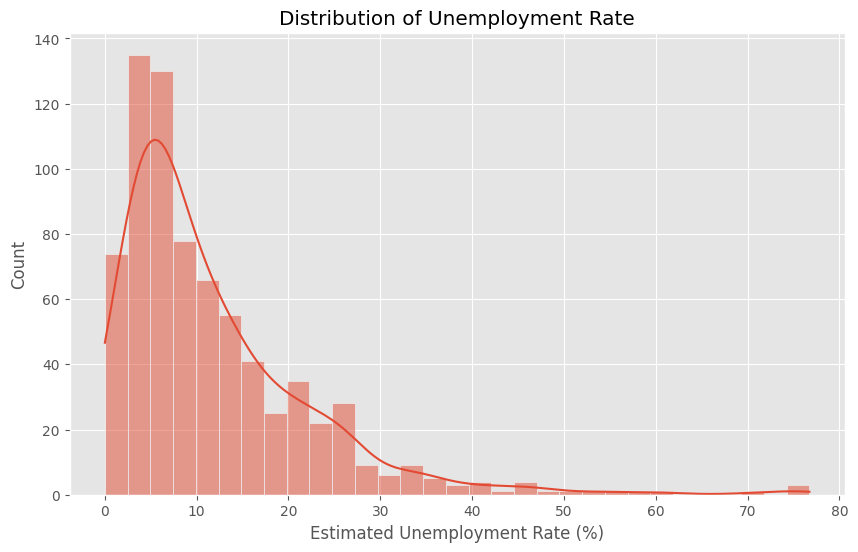

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.show()

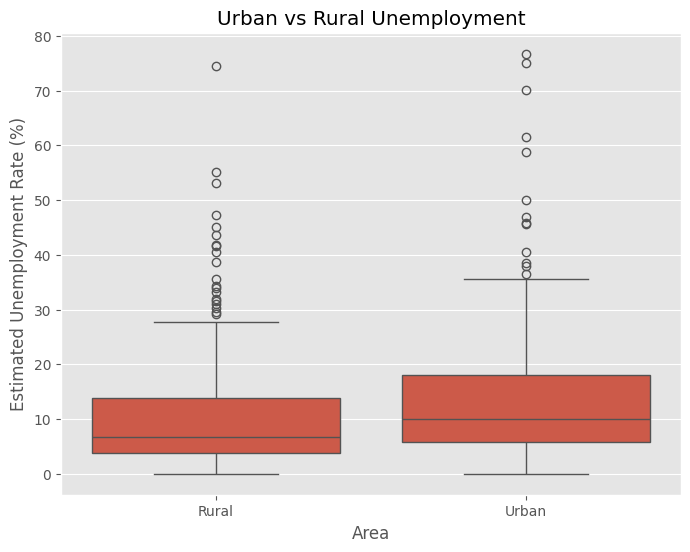

In [14]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")
plt.show()

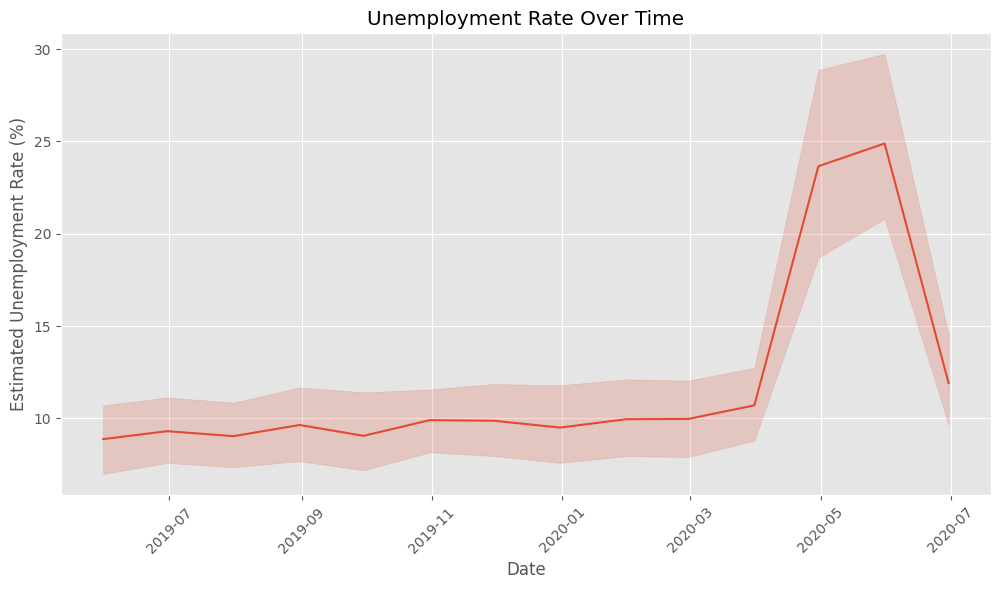

In [15]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Unemployment Rate Over Time")
plt.xticks(rotation=45)
plt.show()

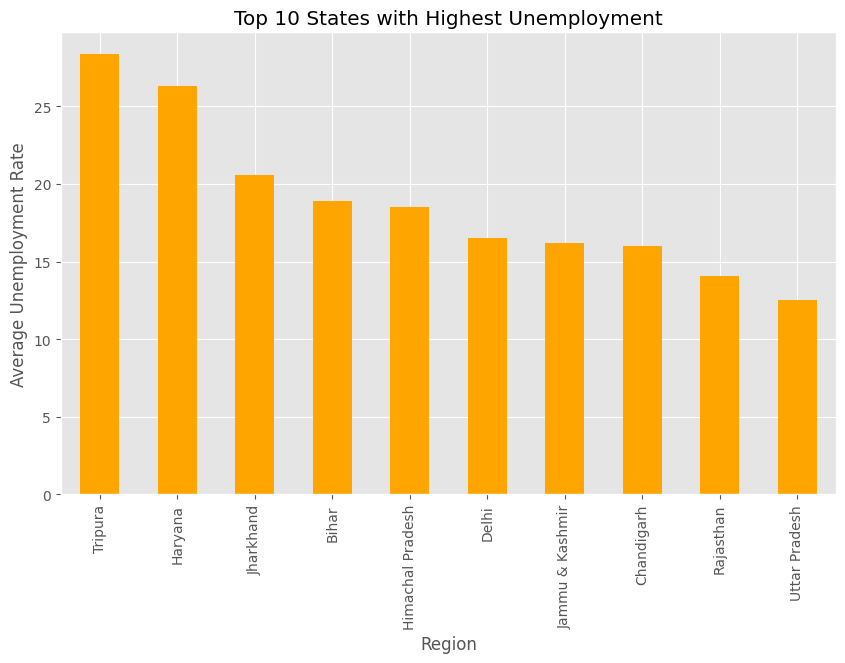

In [16]:
top_states = (
    df.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_states.plot(
    kind='bar',
    color='orange'
)

plt.title("Top 10 States with Highest Unemployment")
plt.ylabel("Average Unemployment Rate")
plt.show()

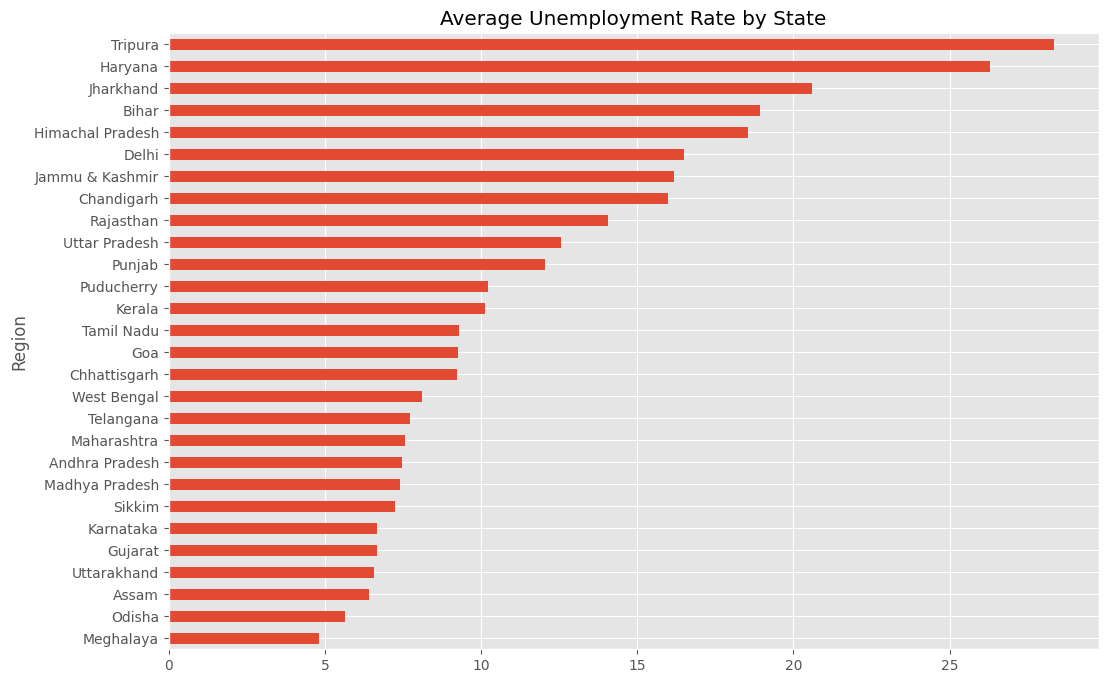

In [17]:
state_avg = (
    df.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_avg.plot(
    kind='barh'
)

plt.title("Average Unemployment Rate by State")
plt.show()

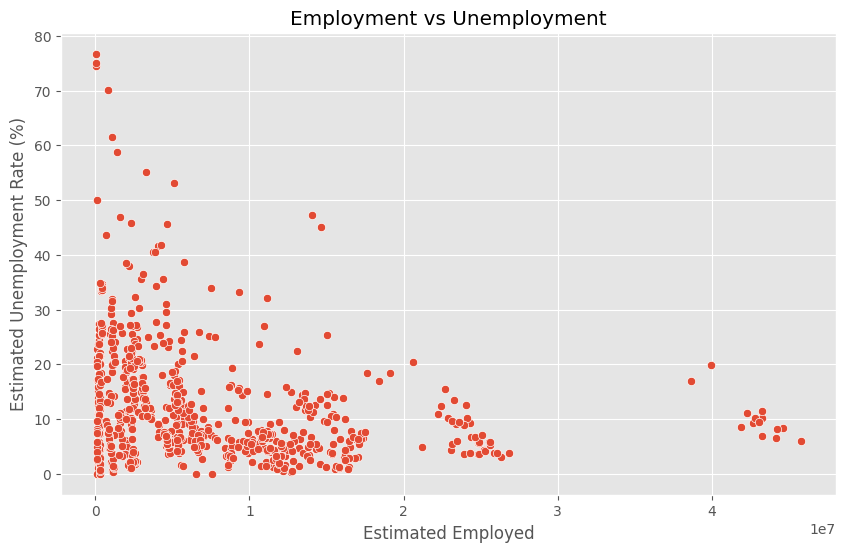

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Employment vs Unemployment")
plt.show()

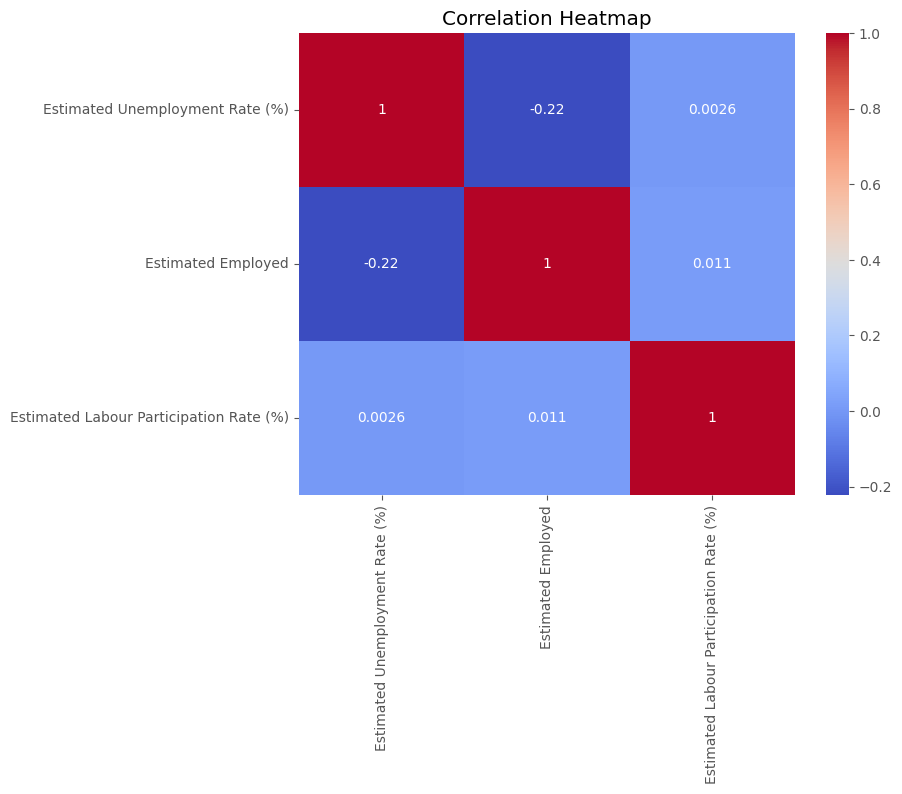

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            'Estimated Unemployment Rate (%)',
            'Estimated Employed',
            'Estimated Labour Participation Rate (%)'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

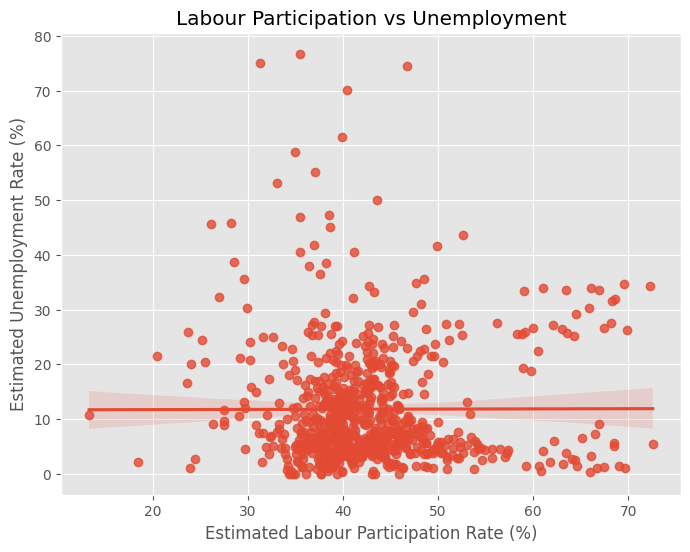

In [20]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Labour Participation vs Unemployment")
plt.show()

In [27]:
print("="*50)
print("COVID IMPACT ANALYSIS")
print("="*50)

before_rate = before[
    'Estimated Unemployment Rate (%)'
].mean()

during_rate = during[
    'Estimated Unemployment Rate (%)'
].mean()

increase = (
    (during_rate-before_rate)
    / before_rate
)*100

print(f"Before COVID : {before_rate:.2f}%")
print(f"During COVID : {during_rate:.2f}%")
print(f"Increase     : {increase:.2f}%")

COVID IMPACT ANALYSIS
Before COVID : 9.61%
During COVID : 20.19%
Increase     : 110.03%


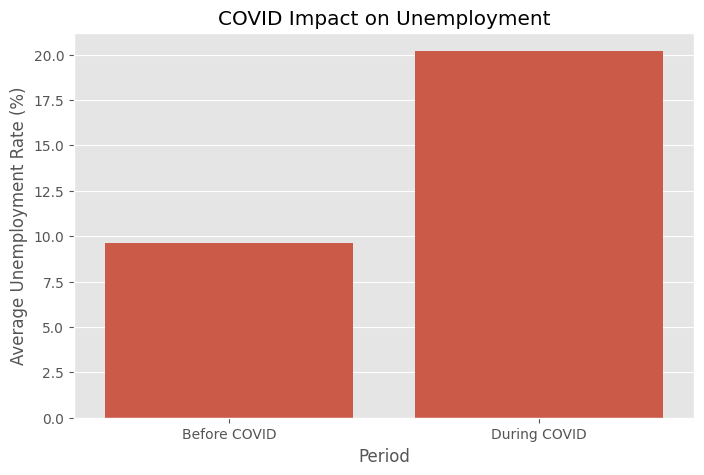

In [28]:
covid_data = pd.DataFrame({
    'Period':['Before COVID','During COVID'],
    'Rate':[
        before[
            'Estimated Unemployment Rate (%)'
        ].mean(),
        during[
            'Estimated Unemployment Rate (%)'
        ].mean()
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=covid_data,
    x='Period',
    y='Rate'
)

plt.title("COVID Impact on Unemployment")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

In [29]:
print("""
Key Insights

1. Unemployment rates varied significantly across states.

2. Urban areas experienced higher unemployment
   than rural areas.

3. COVID-19 caused a sharp increase in
   unemployment levels.

4. Labour participation showed a relationship
   with unemployment trends.

5. Some states were affected much more
   severely than others.
""")


Key Insights

1. Unemployment rates varied significantly across states.

2. Urban areas experienced higher unemployment
   than rural areas.

3. COVID-19 caused a sharp increase in
   unemployment levels.

4. Labour participation showed a relationship
   with unemployment trends.

5. Some states were affected much more
   severely than others.



In [30]:
print("""
Conclusion

1. The unemployment dataset was successfully analyzed using Python.

2. Various visualizations were used to understand
   unemployment trends across India.

3. Significant differences in unemployment rates
   were observed among states and regions.

4. The COVID-19 pandemic had a major impact
   on unemployment levels.

5. Correlation analysis helped understand the
   relationship between employment, labour
   participation, and unemployment.

6. This project demonstrates how data analysis
   techniques can be used to study economic
   indicators and employment trends effectively.
""")


Conclusion

1. The unemployment dataset was successfully analyzed using Python.

2. Various visualizations were used to understand
   unemployment trends across India.

3. Significant differences in unemployment rates
   were observed among states and regions.

4. The COVID-19 pandemic had a major impact
   on unemployment levels.

5. Correlation analysis helped understand the
   relationship between employment, labour
   participation, and unemployment.

6. This project demonstrates how data analysis
   techniques can be used to study economic
   indicators and employment trends effectively.

